# 01 — Language Coverage Exploration

This notebook explores the origins of language codes in this project, all of which is stored in the file `language_codes_comprehensive.csv` with the goal of making visible the interpretative choices that went into determining the full language target set. Future iterations may expand the number of languages whether through adding new standards or simply updates to the underlying language codes, so all numbers should be treated as transitive and historically situated.

The full list of language codes combines five sources into ~880 rows (special-purpose non-language codes like `und` and `zxx` are excluded at build time):

| Source | Role | ~Count | `cldr_version` |
|--------|------|--------|----------------|
| **CLDR 48.2** (npm `cldr-core` + `cldr-localenames-full`) | Scripts, directionality, modern-use flag, official status | ~802 codes | `'48.2.0'` |
| **LOC ISO 639-2** | ISO 639-1/2 code mappings for individual languages | ~190 codes | `''` |
| **Wikimedia** | Language code registry for active Wikipedia projects (the *code* registry — not the article translations used in nb03) | ~270 codes | `''` |
| **CLDR v45 supplement** | ISO 639-3 languages in CLDR 45 but dropped from 48.2 (contributor policy, not linguistics) | 23 codes | `'45'` |
| **SIL ISO 639-3** | English reference names for ~190 CLDR codes absent from CLDR's `en/languages.json` — name-enrichment only, adds no new language codes | — | — |

Family hierarchy (§1.3) also comes from CLDR's `languageGroups.json` — which serialises the **ISO 639-5** family/collection codes (e.g. `ine` Indo-European, `sem` Semitic, `bnt` Bantu) — part of the same `cldr-core` package. Both npm packages are downloaded from the npm registry and cached locally. Cite as: *Unicode CLDR version 48.2.0, https://github.com/unicode-org/cldr-json.*

All 880 codes in the output CSV have a non-empty value for every key column: `language_code`, `language_name` (English), `family_name`, `family_name_reconciled` (Glottolog-cross-validated, see §1.3), `directionality`, and `sources`.

Sections:
- **§1.1 Source Coverage and Overlap** — how many languages come from each source, how sources overlap, CLDR version provenance, and SIL English name enrichment
- **§1.2 Constructing the Target Set** — why ~880? filter strategies, expansion steps, non-modern languages, and directionality overrides
- **§1.3 Language Families** — family distribution, family sizes, and how family assignments were made
- **§1.4 Script and Directionality** — script landscape, LTR/RTL split, directionality by family and source

### Source provenance: institutional origins and editorial criteria

Each of the five registries the pipeline draws on is maintained by a different kind of institution, with a different scope, schedule, and definition of "language." Those differences are not incidental, but determine which languages are visible to the pipeline in the first place. This section walks through each source's organizational context.

**CLDR 48.2 (Unicode Common Locale Data Repository).** Maintained by the [Unicode Consortium](https://www.unicode.org/), the industry standards body that also stewards Unicode and ICU. CLDR was created to give software vendors a shared, royalty-free source of *locale data*: how to format dates in Marathi, how to sort strings in Czech, what direction Arabic runs, what to call English in Japanese. Contributors are predominantly engineers from Apple, Google, Microsoft, IBM, Mozilla, and a handful of national standards bodies. CLDR releases twice a year (a major release in spring, a minor in fall); v48.2 dates from October 2025. The membership and contribution model mean CLDR is pragmatically biased toward languages with corporate, governmental, or large-volunteer sponsorship; its scope is "languages used in real software internationalization," not "all languages." That's why CLDR is the broadest *script and directionality* source in the pipeline but only the *second-broadest* code source. The npm packages used here are `cldr-core` (script metadata, language hierarchies) and `cldr-localenames-full` (English display names); both are downloaded from the npm registry and cached locally.

**CLDR v45 supplement.** Not a separate institution, but a snapshot of codes that were in CLDR 45 (April 2024) but dropped from CLDR 48.2 (October 2025). The inclusin of v45 was somewhat accidental due to using an older version of CLDR but have been retained due to the differential between versions. CLDR's removal criterion is administrative: a locale gets removed when its community stops submitting the Core data (font samples, collation rules, plural rules) required for OS-level internationalization, which the [CLDR 47 release notes](https://cldr.unicode.org/downloads/cldr-47) document as the policy. That criterion has nothing to do with linguistic vitality; a language can be fully translatable by an MT system or LLM without any community ever having submitted CLDR Core data. The pipeline retains all 23 dropped codes with `sources='cldr_v45'` so a language doesn't silently disappear from the analysis when its contributors take a break. The 23 are documented in §1.2; they include seven Indigenous North American languages, American Sign Language, three Ojibwa varieties, and several macrolanguage codes.

**LOC ISO 639-2.** The [US Library of Congress](https://www.loc.gov/standards/iso639-2/) is the official ISO 639-2 Registration Authority, designated by ISO. ISO 639-2 is the standard for two- and three-letter language codes used primarily in *bibliographic cataloging* for MARC records, OAI-PMH metadata, library systems, archival finding aids. The registry is conservative and slow-moving: new codes go through a formal proposal process and are rarely added (a handful per decade). ISO 639-2 is also the source of the bibliographic-vs-terminological distinction: about 20 languages have two codes because library tradition and linguistic naming diverge (`ger`/`deu` German, `fre`/`fra` French, `chi`/`zho` Chinese). The pipeline records both as `iso639_2_b` and `iso639_2_t`. LOC's editorial scope is "languages with substantial published literature," which is why ISO 639-2 covers a broad swath of historically attested and major modern languages but excludes most endangered and minority ones. LOC took over maintaining ISO

**Wikimedia.** [Wikimedia](https://meta.wikimedia.org/wiki/Wikipedias) is Wikipedia's parent organization. The pipeline's Wikimedia source is the list of active Wikipedia projects — every language code that has an editable Wikipedia at `<code>.wikipedia.org`. The list is *community-determined*: a new Wikipedia is approved by the Language Committee based on demonstrated community demand and a working incubator project, not by any external standards body. This produces a code set that famously includes legacy, contested, and Wikipedia-specific identifiers that the ISO authorities never standardized — `bat-smg` (Samogitian, now BCP 47 `sgs`), `zh-min-nan` (Min Nan Chinese, now `nan`), `zh-classical` (Literary Chinese, now `lzh`), `be-x-old` (Belarusian Tarask orthography, now `be-tarask`), `roa-rup` (Aromanian, now `rup`), `fiu-vro` (Võro), `tokipona` (Toki Pona, now `tok`). Some have since been incorporated into BCP 47; others remain Wikipedia-specific. The pipeline preserves the Wikimedia identifier as `wikimedia_code` and resolves to its BCP 47 equivalent in the enrichment layer (see step 1.1's service-support section). Wikimedia is also the source the pipeline uses as a *community-curated reference translation* in nb03 — but only the Wikipedia article content there, not the code list itself.

**CLDR `languageGroups.json` (ISO 639-5).** Same `cldr-core` npm package as the CLDR locale data, but a different file: `languageGroups.json` serializes the [ISO 639-5](https://www.loc.gov/standards/iso639-5/) family/collection codes. ISO 639-5 is also administered by the Library of Congress, on the same standard-of-care basis as 639-2. Codes are three-letter family identifiers — `ine` Indo-European, `sem` Semitic, `bnt` Bantu, `sgn` Sign languages, `crp` Creoles and pidgins. The ISO 639-5 registry mixes *genealogical* groupings (real linguistic families inherited from comparative linguistics) with *geographic* groupings (`cau` Caucasian, `nai` North American Indian, `aus` Australian, `paa` Papuan — areal categories, not phylogenetic ones). It also retains contested or abandoned macrofamilies that contemporary linguistics has split or rejected (`nic` Niger-Kordofanian, `tut` Altaic). This conflation is the problem §1.3 cross-checks against Glottolog: ISO 639-5 is the cleanest *administrative* family registry available, but it isn't the cleanest *linguistic* one.

**SIL ISO 639-3 (auxiliary; name-enrichment only).** [SIL International](https://www.sil.org/) is a US-based organization with roots in missionary linguistics; it is the ISO 639-3 Registration Authority. ISO 639-3 is the broadest ISO language standard — roughly 7,800 codes including thousands of small, endangered, historically attested, and constructed languages that ISO 639-2 does not cover. The standard was developed largely from SIL's [Ethnologue](https://www.ethnologue.com/) inventory, which has been compiled over decades through missionary linguistic fieldwork; SIL retains editorial control over additions, deprecations, and merges. The pipeline uses SIL strictly as a *name-enrichment* source — to populate English display strings for roughly 190 CLDR codes that lack entries in CLDR's `en/languages.json`. It does not add new language codes to the 880. Mentioning SIL's institutional origin matters because its inclusion criteria are *missionary-linguistic* (every speech variety SIL fieldworkers have documented), which produces both the broadest coverage of endangered languages of any registry and a perspective shaped by a particular institutional history.

**Glottolog 5.3 (auxiliary; family reconciliation only).** Discussed in detail in §1.3. Maintained by the [Max Planck Institute for Evolutionary Anthropology](https://glottolog.org/) and the linguistics research community, Glottolog is the academic-linguistics consensus reference for genealogical classification. The pipeline uses it as an *external cross-check* against the ISO 639-5 family hierarchy, not as a source of additional codes. Its institutional context is the inverse of SIL's — peer-reviewed academic linguistics — and the disagreements between Glottolog and ISO 639-5 are themselves a finding documented in §1.3.

**Why this matters for the analysis.** No single registry is "neutral." CLDR encodes what's economically valuable to internationalize; ISO 639-2 encodes what libraries catalog; Wikimedia encodes what communities have rallied to write; ISO 639-3/SIL encodes what missionary linguists have surveyed; ISO 639-5 encodes what an ISO committee has agreed is a family. Each registry's inclusion criteria are visible in the long tail it produces. Combining them — and recording *which* registries each code came from in the `sources` column — lets the analysis distinguish languages that are well-supported across all institutional perspectives from languages that exist in only one tradition. The MT-vs-LLM coverage gap explored in nb03 and nb04 reads very differently depending on which institutional view you start from.

In [35]:
import os
import sys
import pandas as pd
import altair as alt
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))
from scripts.utils import get_data_directory_path

DATA_DIR = get_data_directory_path()
CSV_PATH = os.path.join(DATA_DIR, "metadata_files", "language_codes_comprehensive.csv")

# converters preserves 'nan' (Min Nan Chinese, ISO 639-3) as a string
df = pd.read_csv(CSV_PATH, converters={'language_code': str})

# n_languages is the single source of truth for the target set size used throughout this notebook
n_languages = df["language_code"].nunique()
print(f"Total languages: {n_languages} unique codes ({len(df)} rows)")
print(f"Columns: {list(df.columns)}")

Retrieving translation pipeline data directory path...

Total languages: 880 unique codes (880 rows)
Columns: ['language_code', 'language_name', 'local_name', 'iso639_1', 'iso639_2_t', 'iso639_2_b', 'scripts', 'script_codes', 'primary_script', 'primary_script_code', 'directionality', 'directionality_wikimedia', 'modern_language', 'is_official', 'n_scripts', 'in_iso639_1', 'in_iso639_2', 'in_wikimedia', 'is_group_iso639_2', 'sources', 'cldr_version', 'iso639_5_direct', 'iso639_5_family', 'family_name', 'subfamily_name', 'family_name_reconciled', 'project_language_code', 'wikimedia_code', 'bcp47_tag', 'bcp47_source', 'bcp47_note', 'bcp47_is_project_code', 'service_code_candidates', 'google_nmt_code', 'google_nmt_supported', 'google_translation_llm_code', 'google_translation_llm_supported']


### Counterpoint: comparison with `python-langcodes`

A natural alternative to building a language-code registry from CLDR + LOC + Wikimedia is to use the [`langcodes`](https://github.com/georgkrause/langcodes) library, which validates language tags against the [IANA Language Subtag Registry](https://www.iana.org/assignments/language-subtag-registry) — the authoritative source for BCP 47. `langcodes` and its data package `language_data` ship a snapshot of that registry, and the cell below reports its totals alongside the pipeline's 880-code count.

The two approaches encode different definitions of "what counts as a language code worth tracking." `langcodes` answers a *validation* question (is this tag a well-formed BCP 47 subtag?), so its inventory is the full IANA registry — including every ISO 639-3 entry SIL has ever catalogued, every macrolanguage, every deprecated alias, and every grandfathered tag. The pipeline answers a *coverage* question (which language communities have institutional implementations we can observe?), so its 880 codes are the union of registries that have actually implemented localization, cataloging, or community publishing. Neither is a superset of the other in terms of *information*: `langcodes` carries broader tag validity rules and tag-distance scoring; the pipeline carries scripts, directionality, family classification, Wikimedia aliases, BCP 47 tags, and per-service support flags. The point of running the comparison is to make the registries' scopes visible side by side.


In [ ]:
# Compare with python-langcodes (built on the IANA Language Subtag Registry)
import re
from collections import Counter
import language_data

# langcodes validates against the IANA registry shipped in language_data
reg_path = Path(language_data.__file__).parent / 'data' / 'language-subtag-registry.txt'
records = reg_path.read_text().split('%%\n')

type_counts = Counter()
deprecated_counts = Counter()
for r in records:
    m = re.search(r'^Type:\s*(\S+)', r, re.M)
    if not m:
        continue
    t = m.group(1)
    type_counts[t] += 1
    if re.search(r'^Deprecated:', r, re.M):
        deprecated_counts[t] += 1

file_date_match = re.search(r'^File-Date:\s*(\S+)', records[0], re.M)
file_date = file_date_match.group(1) if file_date_match else '?'

print(f"IANA Language Subtag Registry (shipped with langcodes / language_data)")
print(f"  Snapshot date: {file_date}")
print(f"  Total subtag records: {sum(type_counts.values())}")
print()
print(f"  {'type':<16} {'total':>6}  {'active':>7}  {'deprecated':>11}")
print(f"  {'-'*16} {'-'*6}  {'-'*7}  {'-'*11}")
for t, total in type_counts.most_common():
    dep = deprecated_counts.get(t, 0)
    print(f"  {t:<16} {total:>6}  {total - dep:>7}  {dep:>11}")

lang_active = type_counts['language'] - deprecated_counts['language']
lang_dep    = deprecated_counts['language']
print()
print(f"  Active 'language' subtags (the closest counterpart to our project codes): {lang_active}")
print(f"  Deprecated 'language' subtags (kept for backwards-compat parsing):         {lang_dep}")
print()

print('-' * 72)
print(f"This pipeline: {len(df)} language codes (see Source provenance above).")
print(f"Ratio: langcodes carries ~{lang_active / len(df):.1f}\u00d7 more language subtags than")
print(f"the pipeline includes. The bulk of that gap is ISO 639-3 codes for speech")
print(f"varieties that no institutional implementation (CLDR locale, LOC catalog entry,")
print(f"or active Wikipedia) currently exists for. langcodes will validate them as")
print(f"well-formed tags; the pipeline excludes them because they have no metadata to")
print(f"attach (no script, directionality, modern-use flag, family classification, or")
print(f"service support to record).")


In [2]:
import json
from pathlib import Path
from scripts.experiment.generate_language_codes import MANUAL_LANG_TO_SET5

_json_path = Path("..") / "datasets" / "metadata_files" / "language_family_assignments.json"
with open(_json_path, encoding="utf-8") as _f:
    _json_entries = {e["language_code"]: e for e in json.load(_f)}

def _family_source(row):
    raw_code = row["language_code"]
    # "nan" is the ISO 639-3 code for Min Nan Chinese. Without converters={'language_code': str},
    # pd.read_csv promotes the string "nan" to float NaN. Normalise it back so lookups work.
    code = "nan" if pd.isna(raw_code) else str(raw_code).strip()
    iso2 = str(row.get("iso639_2_t", "") or "").strip()
    fname = row["family_name"]
    if pd.isna(fname) or str(fname).strip() == "":
        return "Unassigned"
    if MANUAL_LANG_TO_SET5.get(code) or MANUAL_LANG_TO_SET5.get(iso2):
        return "Manual mapping"
    if code in _json_entries:
        return "JSON assessment"
    return "Unassigned"

df["family_name_source"] = df.apply(_family_source, axis=1)
print(df["family_name_source"].value_counts().to_string())

family_name_source
Manual mapping     664
JSON assessment    216


In [3]:
# Show the languages that are unassigned to a family to double-check if there are any obvious candidates for manual assignment or JSON assessment.
df[df.family_name_source == "Unassigned"]

,language_code,language_name,local_name,iso639_1,iso639_2_t,iso639_2_b,scripts,script_codes,primary_script,primary_script_code,...,bcp47_tag,bcp47_source,bcp47_note,bcp47_is_project_code,service_code_candidates,google_nmt_code,google_nmt_supported,google_translation_llm_code,google_translation_llm_supported,family_name_source


In [4]:
# Show the original translated DH terms dataset to get a sense of the number of translations and languages covered. This dataset was generated in December 2022.
original_translated_dh_terms = pd.read_csv(os.path.join("..", "historic_materials", "translated_dh_terms.csv"))
original_translated_dh_terms = original_translated_dh_terms[original_translated_dh_terms.term_source == "Digital Humanities"]
print(f"Original translated DH terms: {len(original_translated_dh_terms)} rows")
print(f"Number of actually translated terms: {original_translated_dh_terms[original_translated_dh_terms.translated_term.notnull()].shape[0]} unique translations")
print(f"{original_translated_dh_terms[original_translated_dh_terms.translated_term.isnull()].language_name.nunique()} Languages not translated: {original_translated_dh_terms[original_translated_dh_terms.translated_term.isnull()].language_name.unique().tolist()}")

Original translated DH terms: 185 rows
Number of actually translated terms: 123 unique translations
62 Languages not translated: ['Abkhaz', 'Afar', 'Aragonese', 'Avaric', 'Avestan', 'Bashkir', 'Bislama', 'Breton', 'Chamorro', 'Chechen', 'Chuvash', 'Cornish', 'Cree', 'Dzongkha', 'Faroese', 'Fijian', 'Fula', 'Herero', 'Hiri Motu', 'Interlingua', 'Interlingue', 'Inupiaq', 'Ido', 'Inuktitut', 'Kalaallisut', 'Kanuri', 'Kashmiri', 'Kikuyu, Gikuyu', 'Komi', 'Kongo', 'Kwanyama, Kuanyama', 'Limburgish', 'Luba-Katanga', 'Manx', 'Marshallese', 'Nauru', 'Navajo, Navaho', 'North Ndebele', 'Ndonga', 'Norwegian Nynorsk', 'Nuosu', 'South Ndebele', 'Occitan', 'Ojibwe, Ojibwa', 'Old Church Slavonic', 'Ossetian, Ossetic', 'Pāli', 'Romansh', 'Kirundi', 'Sardinian', 'Northern Sami', 'Sango', 'Swati', 'Tibetan', 'Tswana', 'Tonga', 'Tahitian', 'Venda', 'Volapük', 'Walloon', 'Wolof', 'Zhuang, Chuang']


## 1.1 Source Coverage and Overlap

How many languages come from each source, and how much do they overlap?

Each source covers a different slice of the 880 languages, and many languages appear in more than one. The first chart shows raw counts per source; the second shows the specific source combinations (CLDR only, CLDR + Wikimedia, all three, etc.).

In [5]:
source_flags = {
    "CLDR":      df["sources"].str.contains("cldr", na=False),
    "LOC ISO 639-2": df["in_iso639_2"].fillna(False).astype(bool),
    "Wikimedia": df["in_wikimedia"].fillna(False).astype(bool),
}

summary = pd.DataFrame({
    "source": list(source_flags.keys()),
    "count":  [m.sum() for m in source_flags.values()],
})

bars = alt.Chart(summary).mark_bar().encode(
    y=alt.Y("source:N", sort="-x", title=None),
    x=alt.X("count:Q", title="number of language codes"),
    color=alt.Color("source:N", legend=None, scale=alt.Scale(scheme="tableau10")),
    tooltip=["source:N", "count:Q"],
).properties(width=380, height=120, title="Language codes per source")

text = bars.mark_text(align="left", dx=4, fontSize=10).encode(
    text="count:Q", color=alt.value("black"))

(bars + text) 

alt.LayerChart(...)

In [6]:
# ── Source combination breakdown ─────────────────────────────────────────────
combo_rows = []
for _, row in df.iterrows():
    in_cldr = "cldr" in str(row.get("sources", "") or "")
    in_iso2 = bool(row.get("in_iso639_2"))
    in_wiki = bool(row.get("in_wikimedia"))
    parts = []
    if in_cldr: parts.append("CLDR")
    if in_iso2:  parts.append("ISO 639-2")
    if in_wiki:  parts.append("Wikimedia")
    combo_rows.append(" + ".join(parts) if parts else "None")

df["source_combo"] = combo_rows
combo_counts = df["source_combo"].value_counts().reset_index()
combo_counts.columns = ["combination", "count"]
combo_counts["n_sources"] = combo_counts["combination"].apply(
    lambda c: 0 if c == "None" else len(c.split(" + "))
)
print(combo_counts.to_string(index=False))

_venn_csv = os.path.join(DATA_DIR, "metadata_files", "source_overlap_venn.csv")
combo_counts[["combination", "count"]].to_csv(_venn_csv, index=False)
print(f"\nSaved for RAW Graphs → {_venn_csv}")

# ── Bubble plot ───────────────────────────────────────────────────────────────
# x = number of databases in agreement — a genuinely meaningful axis.
# y = manual jitter to separate bubbles within each column.
# Area ∝ language count; labels printed inside large bubbles, below small ones.
# Single-source colors match the established source palette; multi-source
# bubbles use blended hues (blue+orange→purple, blue+green→teal, etc.).
_COMBO_COLORS = {
    "CLDR":                         "#1976d2",
    "ISO 639-2":                    "#e64a19",
    "Wikimedia":                    "#388e3c",
    "CLDR + ISO 639-2":             "#7040a0",
    "CLDR + Wikimedia":             "#1a8060",
    "ISO 639-2 + Wikimedia":        "#b06820",
    "CLDR + ISO 639-2 + Wikimedia": "#444444",
}

_BUBBLE_POS = {
    "CLDR":                         (1,  0.55),
    "Wikimedia":                    (1,  0.0),
    "ISO 639-2":                    (1, -0.45),
    "CLDR + ISO 639-2":             (2,  0.35),
    "CLDR + Wikimedia":             (2,  0.0),
    "ISO 639-2 + Wikimedia":        (2, -0.30),
    "CLDR + ISO 639-2 + Wikimedia": (3,  0.0),
}

bubble_df = combo_counts.copy()
bubble_df["x"] = bubble_df["combination"].map(lambda c: _BUBBLE_POS[c][0])
bubble_df["y"] = bubble_df["combination"].map(lambda c: _BUBBLE_POS[c][1])

_xscale = alt.Scale(domain=[0.3, 3.7])
_yscale = alt.Scale(domain=[-0.75, 0.85])

bubbles = alt.Chart(bubble_df).mark_circle(opacity=0.88).encode(
    x=alt.X("x:Q", title="source databases in agreement",
            scale=_xscale,
            axis=alt.Axis(values=[1, 2, 3], grid=True, gridDash=[4, 4])),
    y=alt.Y("y:Q", axis=None, scale=_yscale),
    size=alt.Size("count:Q",
                  scale=alt.Scale(type="linear", range=[250, 9000]),
                  legend=None),
    color=alt.Color("combination:N",
                    scale=alt.Scale(
                        domain=list(_COMBO_COLORS.keys()),
                        range=list(_COMBO_COLORS.values()),
                    ),
                    legend=alt.Legend(title="combination")),
    tooltip=["combination:N", "count:Q"],
)

# Count labels: inside (white) for large bubbles, below (dark) for small ones
_big   = bubble_df[bubble_df["count"] > 20].copy()
_small = bubble_df[bubble_df["count"] <= 20].copy()

big_labels = alt.Chart(_big).mark_text(
    color="white", fontWeight="bold", fontSize=11,
    align="center", baseline="middle",
).encode(
    x=alt.X("x:Q", scale=_xscale),
    y=alt.Y("y:Q", scale=_yscale),
    text="count:Q",
)

small_labels = alt.Chart(_small).mark_text(
    color="#333", fontWeight="bold", fontSize=10,
    align="center", dy=22,
).encode(
    x=alt.X("x:Q", scale=_xscale),
    y=alt.Y("y:Q", scale=_yscale),
    text="count:Q",
)

(bubbles + big_labels + small_labels).properties(
    width=480, height=340,
    title=alt.Title(
        "Source consensus across 880 languages",
        subtitle="Bubble area ∝ language count  ·  x = how many databases include these languages",
    ),
).configure_view(strokeWidth=0)

                 combination  count  n_sources
                        CLDR    416          1
CLDR + ISO 639-2 + Wikimedia    218          3
            CLDR + ISO 639-2    181          2
                   Wikimedia     28          1
            CLDR + Wikimedia     20          2
                   ISO 639-2     14          1
       ISO 639-2 + Wikimedia      3          2

Saved for RAW Graphs → /Users/zleblanc/CodingDH/translation_transmogrification_pipeline/datasets/metadata_files/source_overlap_venn.csv


alt.LayerChart(...)

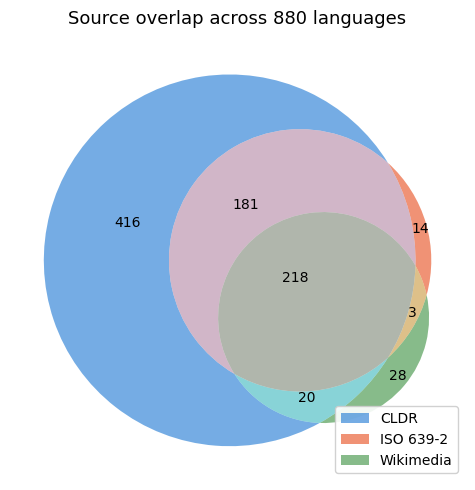

In [7]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def _combo_count(label):
    row = combo_counts[combo_counts["combination"] == label]
    return int(row["count"].iloc[0]) if len(row) else 0

# venn3 subsets order: (Abc, aBc, ABc, abC, AbC, aBC, ABC)
# A=CLDR, B=ISO 639-2, C=Wikimedia
subsets = (
    _combo_count("CLDR"),
    _combo_count("ISO 639-2"),
    _combo_count("CLDR + ISO 639-2"),
    _combo_count("Wikimedia"),
    _combo_count("CLDR + Wikimedia"),
    _combo_count("ISO 639-2 + Wikimedia"),
    _combo_count("CLDR + ISO 639-2 + Wikimedia"),
)

_COLORS = {"CLDR": "#1976d2", "ISO 639-2": "#e64a19", "Wikimedia": "#388e3c"}

fig, ax = plt.subplots(figsize=(7, 5))
v = venn3(
    subsets=subsets,
    set_labels=("", "", ""),
    set_colors=list(_COLORS.values()),
    alpha=0.6,
    ax=ax,
)

legend_handles = [
    mpatches.Patch(facecolor=color, alpha=0.6, label=label)
    for label, color in _COLORS.items()
]
ax.legend(handles=legend_handles, loc="lower right", framealpha=0.9, fontsize=10)

ax.set_title("Source overlap across 880 languages", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

### CLDR version provenance and the v45 supplement

The `cldr_version` column records which CLDR release each row came from:

| `cldr_version` | Rows | Meaning |
|---|---|---|
| `'48.2.0'` | ~802 | Core CLDR 48.2 JSON fetch — authoritative for scripts, directionality, modern-use flag |
| `'45'` | 23 | CLDR v45 supplement — languages present in CLDR 45, dropped in 48.2 |
| `''` | ~55 | Wikimedia-only or LOC-only rows — no CLDR data at all |

**Why the supplement exists.** CLDR removes locales when their communities stop submitting Core data — font samples, collation rules, date formats — required for OS and software internationalisation. Between CLDR 45 and 48.2, 23 ISO 639-3 languages were removed on this basis (see the [CLDR 47 release notes](https://cldr.unicode.org/downloads/cldr-47) for the stated policy). That criterion does not apply here: a language can be fully translatable by an LLM without any community ever having submitted a CLDR locale file. All 23 are valid, living languages; the pipeline retains them marked `sources='cldr_v45'` so they appear in all downstream analysis alongside the rest.

Note: the source overlap chart above treats supplement codes as "CLDR only" (since their `sources` field contains the string `cldr`). The chart below isolates them explicitly.

In [8]:
if "cldr_version" not in df.columns:
    print("⚠  cldr_version not in CSV — re-run generate_language_codes.py to see this section.")
    dropped_chart = None
else:
    _ver_label = {
        "48.2.0": "CLDR 48.2 (primary)",
        "45":     "CLDR v45 supplement",
        "":       "Wikimedia / LOC only",
    }
    ver_counts = (
        df["cldr_version"].fillna("").map(_ver_label).fillna("other")
        .value_counts()
        .rename_axis("source")
        .reset_index(name="count")
    )
    print("Version provenance breakdown:")
    print(ver_counts.to_string(index=False))
    print()

    supp = (
        df[df["cldr_version"] == "45"]
        [["language_code", "language_name", "directionality", "family_name"]]
        .sort_values(["family_name", "language_code"])
        .reset_index(drop=True)
    )
    print(f"CLDR v45 supplement — {len(supp)} languages retained from CLDR 45:")
    print(supp.to_string(index=False))

    # ── Chart: supplement languages by family ────────────────────────────────
    supp_fam = supp["family_name"].value_counts().reset_index()
    supp_fam.columns = ["family", "count"]

    bars = alt.Chart(supp_fam).mark_bar(color="#c0392b").encode(
        y=alt.Y("family:N", sort="-x", title=None),
        x=alt.X("count:Q", title="languages in supplement"),
        tooltip=["family:N", "count:Q"],
    )
    text = bars.mark_text(align="left", dx=4, fontSize=10).encode(
        text="count:Q", color=alt.value("black"))

    dropped_chart = (bars + text).properties(
        width=420, height=220,
        title=alt.Title(
            "CLDR v45 supplement: 23 languages by family",
            subtitle="Dropped from CLDR 48.2 for contributor-policy reasons, not linguistic ones — retained here for scholarly translation coverage",
        )
    )
dropped_chart

Version provenance breakdown:
              source  count
 CLDR 48.2 (primary)    812
Wikimedia / LOC only     45
 CLDR v45 supplement     23

CLDR v45 supplement — 23 languages retained from CLDR 45:
language_code              language_name directionality                     family_name
          shu             Chadian Arabic            rtl          Afro-Asiatic languages
          lou           Louisiana Creole            ltr             Creoles and pidgins
          ike Eastern Canadian Inuktitut            ltr          Eskimo-Aleut languages
          gom               Goan Konkani            ltr         Indo-European languages
          hax             Southern Haida            ltr                Language isolate
          hdn             Northern Haida            ltr                Language isolate
          lsm                     Saamia            ltr     Niger-Kordofanian languages
          mye                      Myene            ltr     Niger-Kordofanian languages
       

alt.LayerChart(...)

### English Name Coverage: SIL ISO 639-3 Enrichment

CLDR's English locale-names file (`en/languages.json`) covers ~693 of its ~802 language codes. The remaining ~190 CLDR codes have no entry and fall through to `en_names.get(code, code)` in `parse_cldr_json.py` — leaving the ISO code itself as the `language_name`. Combined with a small number of codes from other sources that also lacked names, **216 of the 880 codes (~25%) had code-as-name** before enrichment.

These are not obscure codes: they include living languages like Abaza (`abq`), Bhilali (`bhi`), Kanauji (`bjj`), and Balanta-Ganja (`bjt`), as well as ancient and undeciphered scripts like Mycenaean Greek (`gmy`), Linear A (`lab`), Carian (`xcr`), and Meroitic (`xmr`).

`enrich_language_names_from_sil()` in `generate_language_codes.py` patches these rows using SIL's ISO 639-3 reference name table (~7,900 codes), which covers 214 of the 216. The remaining two are filled from a hardcoded `_SIL_NAME_OVERRIDES` constant:

| Code | Name | Reason not in SIL |
|------|------|-------------------|
| `kro` | Kru languages | ISO 639-5 group code; SIL ISO 639-3 covers individual languages only |
| `tokipona` | Toki Pona | Constructed language; Wikimedia-only composite tag with no ISO 639-3 assignment |

After enrichment, all 880 codes have a human-readable `language_name`. The table below shows the 216 previously unnamed codes and the names now assigned.

In [9]:
import json as _json

# Ground truth: which codes CLDR's en/languages.json directly names
_en_langs_path = os.path.join(
    DATA_DIR, "metadata_files", "cldr-cache",
    "cldr-localenames-full-48.2.0", "main", "en", "languages.json"
)
with open(_en_langs_path, encoding="utf-8") as _f:
    _cldr_en_names = set(
        _json.load(_f)["main"]["en"]["localeDisplayNames"]["languages"].keys()
    )

# SIL reference names
_sil_path = os.path.join(DATA_DIR, "metadata_files", "cldr-cache", "iso-639-3.tab")
_sil = pd.read_csv(_sil_path, sep="\t", dtype=str, na_filter=False)
_sil_names = dict(zip(_sil["Id"].str.strip(), _sil["Ref_Name"].str.strip()))
_sil_overrides = {"kro": "Kru languages", "tokipona": "Toki Pona"}

# Previously unnamed codes fall into two groups:
# 1. CLDR codes (sources contains 'cldr', not 'cldr_v45') absent from CLDR's en/languages.json
# 2. The two hardcoded overrides (kro: ISO 639-5 group code; tokipona: Wikimedia-only tag)
#    — tokipona is wikimedia_only so would otherwise slip through the CLDR filter
_unnamed_mask = (
    (
        df["sources"].str.contains("cldr", na=False)
        & ~df["sources"].str.fullmatch("cldr_v45", na=False)
        & ~df["language_code"].isin(_cldr_en_names)
    )
    | df["language_code"].isin(_sil_overrides)
)

def _fill_source(code):
    if code in _sil_overrides:
        return "Hardcoded override"
    if code in _sil_names:
        return "SIL ISO 639-3"
    return "Other"

_sil_filled = df[_unnamed_mask].copy()
_sil_filled["fill_source"] = _sil_filled["language_code"].map(_fill_source)

print(f"Codes with no CLDR English name (previously code-as-name): {len(_sil_filled)}")
print(f"  Filled by SIL ISO 639-3:  {(_sil_filled['fill_source'] == 'SIL ISO 639-3').sum()}")
print(f"  Filled by override:       {(_sil_filled['fill_source'] == 'Hardcoded override').sum()}")
print(f"  Still unnamed:            {(_sil_filled['fill_source'] == 'Other').sum()}")
print()

_sil_filled[["language_code", "language_name", "family_name", "modern_language", "fill_source"]].sort_values(
    ["family_name", "language_code"]
).reset_index(drop=True)

Codes with no CLDR English name (previously code-as-name): 216
  Filled by SIL ISO 639-3:  214
  Filled by override:       2
  Still unnamed:            0



,language_code,language_name,family_name,modern_language,fill_source
0,aii,Assyrian Neo-Aramaic,Afro-Asiatic languages,True,SIL ISO 639-3
1,apc,Levantine Arabic,Afro-Asiatic languages,True,SIL ISO 639-3
2,apd,Sudanese Arabic,Afro-Asiatic languages,True,SIL ISO 639-3
3,grr,Taznatit,Afro-Asiatic languages,True,SIL ISO 639-3
4,mey,Hassaniyya,Afro-Asiatic languages,True,SIL ISO 639-3
...,...,...,...,...,...
211,tts,Northeastern Thai,Tai-Kadai languages,True,SIL ISO 639-3
212,lab,Linear A,Undeciphered script,False,SIL ISO 639-3
213,kca,Khanty,Uralic languages,True,SIL ISO 639-3
214,mns,Mansi,Uralic languages,True,SIL ISO 639-3


### The `nan` edge case: Min Nan Chinese

**Min Nan Chinese** (`nan`) is ISO 639-3 code `nan` — the same three characters Python uses for *Not a Number*. When `pd.read_csv` encounters the string `"nan"` in a column with no explicit converter, it silently promotes it to `float('nan')`, erasing the code. The language is in the dataset and its family is correctly assigned, but any code-keyed lookup silently misses it without the fix.

**Why the pipeline is safe.** `load_language_codes()` reads the CSV with `converters={'language_code': str}`, which forces `"nan"` to stay a string. Any code that reads this CSV without that converter is exposed to the silent drop.

**How `_family_source` handles it.** The function detects `pd.isna(raw_code)` and normalises to the string `"nan"` before any lookup. `nan` is now in `MANUAL_LANG_TO_SET5` (mapped to `'zhx'` — Sinitic languages → Sino-Tibetan), so it correctly returns **"Manual mapping"** and the "Unassigned" count is zero.

### Wikimedia-only language codes

Languages that appear in Wikimedia but not CLDR fall into four distinct classes:

- **Composite codes Wikimedia invented** (`bat-smg`, `be-x-old`, `fiu-vro`, `map-bms`, `nds-nl`, `roa-rup`, `zh-classical`, `zh-min-nan`, `zh-tw`, `zh-yue`, `uz_AF`): community-assigned `xx-yyy` or `xx_YY` tags with no ISO equivalent. These represent writing communities that achieved Wikipedia scale but were never submitted to ISO for standardisation.
- **ISO 639-3-only languages below CLDR's threshold**: codes like `bcl`, `bxr`, `cdo`, `diq`, `mrh`, `nrm` have ISO 639-3 entries but CLDR only tracks languages used in OS/software localisation — a narrower criterion than "has a Wikipedia."
- **Contested, collective, or deprecated ISO status**: `mo` (Moldovan, ISO 639-1 code withdrawn — treated as Romanian), `nah` (Nahuatl, an ISO 639-2 *collective* cover code for the whole language family), `crn` (Montenegrin, ISO 639-3 `cnr` only assigned 2017), and `als` (a code collision — ISO 639-3 `als` is Tosk Albanian, not Alemannic German, which is `gsw`).
- **Constructed language**: `tokipona` (Toki Pona, created 2001); ISO 639-3 code `tok` was only assigned in 2022.

The `crn`/Montenegrin case is the sharpest failure mode in the dataset: the model family-assignment used only the bare code, inferred Woods Cree (for whom ISO 639-3 `crn` *is* the correct assignment), and produced a row saying Montenegrin belongs to the Indigenous North American family. The error was only discoverable because the pipeline logs the rationale alongside each assignment. It is corrected in `MANUAL_LANG_TO_SET5` and `language_family_assignments.json`.

### Translation Service Support Coverage

A parallel dimension of source coverage: which of the 880 language codes are *advertised* as supported by major commercial translation services? The `language_codes_comprehensive.csv` carries this information in two columns derived from `service_language_code_support.csv` (frozen from Google's published lists):

- `google_nmt_supported` — official support in Google's standard Neural Machine Translation API (the broad-coverage workhorse, ~190 languages)
- `google_translation_llm_supported` — official support in Google's newer Translation LLM endpoint (the higher-quality but smaller-coverage tier, ~115 languages)

**Why both matter for our argument**: the Translation LLM is the higher-quality model tier; the NMT is what scales. The gap between them — how many languages drop from "LLM-grade" to "NMT-grade" to "unsupported" — is one operational measure of the long tail this paper studies.

**Note on identifier matching**: the support flags are populated by `add_service_language_codes()`, which matches our internal `language_code` (or its BCP 47-normalized `bcp47_tag`) against the exact codes Google's documentation lists. Some languages appear under multiple aliases (Hebrew `iw` and `he`, Javanese `jw` and `jv`, etc.) — those are recognized via the `DEPRECATED_LANGUAGE_SUBTAG_PREFERRED` map so a match on either alias still flags the language as supported.

#### Upstream support manifest — what Google's API itself says

Before counting how many of *our* 880 codes Google supports, the upstream snapshot is worth looking at on its own: how many languages does Google's API claim to support at all, when was that list captured, and where does it intersect the pipeline's identifier space?

The block below loads `service_language_code_support.csv` directly (refreshed via `python -m scripts.experiment.refresh_service_support`, which calls Translation v3's `get_supported_languages`) and reports per-service totals, snapshot date and source, and how many of Google's supported codes land on a row in our 880 — vs. how many are locale variants (e.g. `ar-SA`, `es-MX`, `zh-TW`) the pipeline doesn't split.


In [10]:
# Upstream support manifest — straight from the snapshot CSV
support_path = Path('..') / 'datasets' / 'metadata_files' / 'service_language_code_support.csv'
support = pd.read_csv(support_path, dtype=str, na_filter=False)

print(f'Manifest path: {support_path}')
print()
print(f"{'service':<28} {'rows':>5}  {'snapshot_date':<14}  snapshot_source")
print('-' * 100)
for service, sdf in support.groupby('service'):
    snap = sdf['snapshot_date'].iloc[0] if 'snapshot_date' in sdf.columns else '\u2014'
    src  = sdf['snapshot_source'].iloc[0] if 'snapshot_source' in sdf.columns else '\u2014'
    print(f'{service:<28} {len(sdf):>5}  {snap:<14}  {src}')

print()
print("Overlap with the 880-row pipeline (a 'pipeline match' = Google's code was selected by a row in df):")
for service, sdf in support.groupby('service'):
    matched_col = f'{service}_code'
    if matched_col not in df.columns:
        print(f'  {service}: column {matched_col} not in df; skipping')
        continue
    pipeline_codes_matched = set(df[matched_col].dropna()) - {''}
    google_codes = set(sdf['service_code'])
    in_pipeline = google_codes & pipeline_codes_matched
    out_of_pipeline = google_codes - pipeline_codes_matched
    print(f'  {service}: {len(google_codes)} supported  \u2192  '
          f'{len(in_pipeline)} match a pipeline row, '
          f'{len(out_of_pipeline)} do not')
    if out_of_pipeline:
        examples = sorted(out_of_pipeline)[:10]
        print(f"      out-of-pipeline examples: {', '.join(examples)}")


Manifest path: ../datasets/metadata_files/service_language_code_support.csv

service                       rows  snapshot_date   snapshot_source
----------------------------------------------------------------------------------------------------
google_nmt                     196  2026-06-15      translate_v3.get_supported_languages
google_translation_llm         127  2026-06         manual_paste_from_cloud.google.com_docs

Overlap with the 880-row pipeline (a 'pipeline match' = Google's code was selected by a row in df):
  google_nmt: 196 supported  →  181 match a pipeline row, 15 do not
      out-of-pipeline examples: alz, bts, btx, cnh, dov, fr-CA, he, hrx, jv, ktu
  google_translation_llm: 127 supported  →  86 match a pipeline row, 41 do not
      out-of-pipeline examples: ar-SA, bn-IN, bs-Cyrl, en-AU, en-CA, en-GB, en-NZ, en-PH, en-US, en-ZA


In [11]:
# Service-coverage summary
service_cov = pd.DataFrame({
    'tier':  ['LLM-grade (Translation LLM)', 'NMT-grade (standard NMT)',
              'NMT only (no LLM support)', 'Neither service'],
    'count': [
        int(df['google_translation_llm_supported'].fillna(False).sum()),
        int(df['google_nmt_supported'].fillna(False).sum()),
        int((df['google_nmt_supported'].fillna(False) & ~df['google_translation_llm_supported'].fillna(False)).sum()),
        int((~df['google_nmt_supported'].fillna(False) & ~df['google_translation_llm_supported'].fillna(False)).sum()),
    ],
})
service_cov['pct'] = (service_cov['count'] / len(df) * 100).round(1)
print(f'Total pipeline languages: {len(df)}')
print()
print(service_cov.to_string(index=False))

Total pipeline languages: 880

                       tier  count  pct
LLM-grade (Translation LLM)     87  9.9
   NMT-grade (standard NMT)    184 20.9
  NMT only (no LLM support)     98 11.1
            Neither service    695 79.0


In [12]:
# Three buckets: in LLM, in NMT only, in neither
buckets = pd.DataFrame({
    'tier':  ['Translation LLM',
              'NMT only',
              'Unsupported by both'],
    'count': [
        int(df['google_translation_llm_supported'].fillna(False).sum()),
        int((df['google_nmt_supported'].fillna(False) & ~df['google_translation_llm_supported'].fillna(False)).sum()),
        int((~df['google_nmt_supported'].fillna(False) & ~df['google_translation_llm_supported'].fillna(False)).sum()),
    ],
})
buckets['pct'] = (buckets['count'] / len(df) * 100).round(1)
buckets['label'] = buckets.apply(lambda r: f"{r['count']} ({r['pct']:.1f}%)", axis=1)

tier_colors = {
    'Translation LLM':     '#1976d2',
    'NMT only':            '#c0680c',
    'Unsupported by both': '#9e9e9e',
}

bar = alt.Chart(buckets).mark_bar().encode(
    y=alt.Y('tier:N', sort=['Translation LLM', 'NMT only', 'Unsupported by both'], title=None),
    x=alt.X('count:Q', title='languages'),
    color=alt.Color('tier:N',
                    scale=alt.Scale(domain=list(tier_colors), range=list(tier_colors.values())),
                    legend=None),
    tooltip=['tier:N', 'count:Q', 'pct:Q'],
).properties(
    width=420, height=140,
    title=alt.Title(
        'Google Translation service coverage across 880 pipeline languages',
        subtitle='The unsupported-by-both bucket is the long tail this paper studies',
    ),
)
text = bar.mark_text(align='left', dx=5, fontSize=11).encode(text='label:N', color=alt.value('black'))
(bar + text)

alt.LayerChart(...)

In [13]:
# Sanity: how often does our internal `language_code` already match Google's exact code?
for col in ['google_nmt_code', 'google_translation_llm_code']:
    matched = df[df[col].fillna('').astype(str).str.len() > 0]
    if matched.empty:
        continue
    same = (matched[col].astype(str) == matched['language_code'].astype(str)).sum()
    print(f'{col}: {len(matched)} matched | {same} match the project code directly | '
          f'{len(matched)-same} matched via BCP47 / ISO alias')

google_nmt_code: 184 matched | 178 match the project code directly | 6 matched via BCP47 / ISO alias
google_translation_llm_code: 87 matched | 84 match the project code directly | 3 matched via BCP47 / ISO alias


## 1.2 Constructing the Target Set

Why 880? Four candidate target sets range from the most conservative (Wikimedia-only: 269 languages with active Wikipedia projects) to the broadest (all 880 codes). Each filter represents a different answer to: *which languages should we ask the pipeline to translate?*

The pipeline uses **all 880** — including languages without Wikipedia presence, without ISO 639-2 codes, and including languages CLDR marks as "non-modern." The sections below justify each step of that expansion.

In [14]:
filters = {
    f"All {n_languages} (pipeline default)":  pd.Series([True] * len(df)),
    "Wikimedia only":                          df["in_wikimedia"].fillna(False),
    "Modern + ISO 639-2 or Wikimedia":         df["modern_language"] & (df["in_iso639_2"] | df["in_wikimedia"]),
    "All modern":                              df["modern_language"].fillna(False),
}

rows = []
for label, mask in filters.items():
    subset = df[mask]
    rows.append({
        "filter": label,
        "total":  len(subset),
        "ltr":    (subset["directionality"] == "ltr").sum(),
        "rtl":    (subset["directionality"] == "rtl").sum(),
        "iso639_1": subset["in_iso639_1"].sum(),
        "iso639_2": subset["in_iso639_2"].sum(),
        "wikimedia": subset["in_wikimedia"].sum(),
    })
filter_df = pd.DataFrame(rows)
filter_df

,filter,total,ltr,rtl,iso639_1,iso639_2,wikimedia
0,All 880 (pipeline default),880,802,78,187,416,269
1,Wikimedia only,269,253,16,185,221,269
2,Modern + ISO 639-2 or Wikimedia,452,428,24,186,404,267
3,All modern,855,787,68,186,404,267


In [15]:
filter_order = filter_df["filter"].tolist()

bar = alt.Chart(filter_df).mark_bar().encode(
    y=alt.Y("filter:N", sort=filter_order, title=None),
    x=alt.X("total:Q", title="languages in target set"),
    color=alt.Color("filter:N", legend=None, scale=alt.Scale(scheme="tableau10")),
    tooltip=["filter:N", "total:Q", "ltr:Q", "rtl:Q", "wikimedia:Q"],
).properties(width=420, height=160, title="Target set size by filter strategy")

text = bar.mark_text(align="left", dx=4, fontSize=10).encode(
    text="total:Q", color=alt.value("black"))

bar + text

alt.LayerChart(...)

In [16]:
# Stacked LTR/RTL breakdown
dir_rows = []
for _, r in filter_df.iterrows():
    dir_rows.append({"filter": r["filter"], "direction": "LTR", "count": r["ltr"]})
    dir_rows.append({"filter": r["filter"], "direction": "RTL", "count": r["rtl"]})
dir_df = pd.DataFrame(dir_rows)

dir_bar = alt.Chart(dir_df).mark_bar().encode(
    y=alt.Y("filter:N", sort=filter_order, title=None),
    x=alt.X("count:Q", title="languages"),
    color=alt.Color("direction:N",
        scale=alt.Scale(domain=["LTR", "RTL"], range=["#1976d2", "#e64a19"]),
        title="direction"),
    tooltip=["filter:N", "direction:N", "count:Q"],
).properties(width=420, height=160, title="LTR / RTL split by filter strategy")

dir_bar

alt.Chart(...)

### Expansion Steps

Moving from Wikimedia-only (269) to the full 880 adds two further tranches: languages in ISO 639-2 or Wikimedia (452 total, +183), then all CLDR-modern languages (855 total, +403), then the 25 non-modern languages discussed below.

In [17]:
wiki_mask  = df["in_wikimedia"].fillna(False)
iso2_mask  = df["modern_language"] & (df["in_iso639_2"] | df["in_wikimedia"])
modern_mask = df["modern_language"].fillna(False)

# Languages in ISO2-or-Wikimedia but NOT in Wikimedia-only
iso2_additions = df[iso2_mask & ~wiki_mask][
    ["language_code", "language_name", "directionality", "family_name", "sources"]
].sort_values("language_name").reset_index(drop=True)

# Languages in All-Modern but NOT in ISO2-or-Wikimedia
modern_additions = df[modern_mask & ~iso2_mask][
    ["language_code", "language_name", "directionality", "family_name", "sources"]
].sort_values("language_name").reset_index(drop=True)

print(f"Added by expanding to ISO 639-2 or Wikimedia: {len(iso2_additions)}")
print(f"Added by expanding to all modern: {len(modern_additions)}")
print()

print("=== ISO 639-2 expansion additions (sample) ===")
print(iso2_additions.head(20).to_string(index=False))

Added by expanding to ISO 639-2 or Wikimedia: 185
Added by expanding to all modern: 403

=== ISO 639-2 expansion additions (sample) ===
language_code language_name directionality                     family_name       sources
          ace      Acehnese            ltr          Austronesian languages cldr|iso639_2
          ach         Acoli            ltr          Nilo-Saharan languages cldr|iso639_2
          ada       Adangme            ltr     Niger-Kordofanian languages cldr|iso639_2
          ady        Adyghe            ltr             Caucasian languages cldr|iso639_2
          afh      Afrihili            ltr            Artificial languages      loc_only
          ain          Ainu            ltr                Language isolate cldr|iso639_2
          ale         Aleut            ltr          Eskimo-Aleut languages cldr|iso639_2
          grc Ancient Greek            ltr         Indo-European languages cldr|iso639_2
          anp        Angika            ltr         Indo-Europea

In [18]:
print("=== Additional languages from CLDR-only (all modern, no ISO 639-2 or Wikimedia) ===")
print(modern_additions.to_string(index=False))

=== Additional languages from CLDR-only (all modern, no ISO 639-2 or Wikimedia) ===
language_code                  language_name directionality                       family_name  sources
          abq                          Abaza            ltr               Caucasian languages     cldr
          abr                          Abron            ltr       Niger-Kordofanian languages     cldr
          agq                          Aghem            ltr       Niger-Kordofanian languages     cldr
          bss                         Akoose            ltr       Niger-Kordofanian languages     cldr
          akz                        Alabama            ltr   North American Indian languages     cldr
          arq                Algerian Arabic            rtl            Afro-Asiatic languages     cldr
          ase         American Sign Language            ltr                    Sign languages cldr_v45
          amo                            Amo            ltr       Niger-Kordofanian language

### Non-Modern Languages

CLDR (Unicode's Common Locale Data Repository) includes a type flag that distinguishes languages it considers "modern" from those it labels `'O'` — a catch-all for ancient, extinct, and constructed languages. The `modern_language` column in `language_codes_comprehensive.csv` is derived directly from this flag (`modern_language = (cldr_type != 'O')`). It reflects CLDR's purpose — building locale data for commercial software internationalization — not a linguistic or scholarly judgment about which languages matter.

**We do not filter on it.** The pipeline includes all 880 languages, and these 25 appear in every downstream analysis alongside the rest. Two of them have active Wikipedia projects and one has an ISO 639-1 code — the same markers of real-world use we apply to any other language. The fact that an LLM attempts or refuses to translate into Latin, Linear A, or Esperanto is itself a finding worth keeping in the data.

The table below is a record of which languages CLDR chose to flag, not a list of languages the pipeline excludes.

In [19]:
non_modern = df[~df["modern_language"].fillna(True)].copy()
non_modern["has_wikipedia"] = non_modern["in_wikimedia"].fillna(False)
non_modern["has_iso639_1"]  = non_modern["in_iso639_1"].fillna(False)
non_modern["has_iso639_2"]  = non_modern["in_iso639_2"].fillna(False)

display_cols = ["language_code", "language_name", "directionality",
                "has_wikipedia", "has_iso639_1", "has_iso639_2", "family_name"]

print(f"Total non-modern: {len(non_modern)}")
print(f"  With active Wikipedia: {non_modern['has_wikipedia'].sum()}")
print(f"  With ISO 639-1 code:   {non_modern['has_iso639_1'].sum()}")
print()
non_modern[display_cols].sort_values(
    ["has_wikipedia", "has_iso639_1"], ascending=False
).reset_index(drop=True)

Total non-modern: 25
  With active Wikipedia: 2
  With ISO 639-1 code:   1



,language_code,language_name,directionality,has_wikipedia,has_iso639_1,has_iso639_2,family_name
0,arc,Aramaic,rtl,True,False,True,Afro-Asiatic languages
1,got,Gothic,ltr,True,False,True,Indo-European languages
2,ae,Avestan,rtl,False,True,True,Indo-European languages
3,akk,Akkadian,ltr,False,False,True,Afro-Asiatic languages
4,ecy,Eteocypriot,rtl,False,False,False,Indo-European languages
5,egy,Ancient Egyptian,ltr,False,False,True,Afro-Asiatic languages
6,gmy,Mycenaean Greek,rtl,False,False,False,Indo-European languages
7,hit,Hittite,ltr,False,False,True,Indo-European languages
8,lab,Linear A,ltr,False,False,False,Undeciphered script
9,mnc,Manchu,ltr,False,False,True,Altaic languages


### A structural edge case: `uz_AF`

`uz_AF` (Afghan Uzbek) is a Wikimedia-only code for the variety spoken in northern Afghanistan, which retains Perso-Arabic script — Wikimedia correctly marks it `rtl`. But `uz_AF` has no CLDR script data, so the script-based pass defaults to `ltr`.

The pipeline corrects this with a fallback in `build_comprehensive`: for any Wikimedia-only code with no CLDR script data, if `directionality_wikimedia == 'rtl'`, restore `rtl`. This is the one case in the dataset where the less institutionally curated source (Wikimedia) is closer to empirical truth than the CLDR-derived default.

## 1.3 Language Families

Family membership is the primary grouping variable for downstream analysis. Family assignments here are anchored in **ISO 639-5** (the ISO standard for language families/collections, e.g. `ine` Indo-European, `nic` Niger-Kordofanian, `sgn` Sign languages), accessed via CLDR's `languageGroups.json` and supplemented by a manual map plus a JSON fallback for the codes ISO 639-5 doesn't cover. The three sub-sections here document how families distribute across filter strategies, how large individual families are, and where each family assignment came from — with an external cross-check against Glottolog 5.3 at the end.

In [20]:
family_rows = []
for label, mask in filters.items():
    subset = df[mask]
    counts = subset["family_name"].fillna("Unknown / unassigned").value_counts().reset_index()
    counts.columns = ["family", "count"]
    counts["filter"] = label
    family_rows.append(counts)
family_long = pd.concat(family_rows, ignore_index=True)

# Focus on top 15 families across all filters
top_families = (
    family_long.groupby("family")["count"].sum()
    .nlargest(15).index.tolist()
)
plot_df = family_long[family_long["family"].isin(top_families)]

alt.Chart(plot_df).mark_bar().encode(
    x=alt.X("count:Q", title="languages"),
    y=alt.Y("family:N", sort="-x", title=None),
    color=alt.Color("filter:N", sort=list(filters.keys()),
        scale=alt.Scale(scheme="tableau10"), title="filter"),
    xOffset="filter:N",
    tooltip=["filter:N", "family:N", "count:Q"],
).properties(
    width=500, height=420,
    title="Top 15 language families by filter strategy",
)

alt.Chart(...)

### Family Size Distribution

Family size varies from Indo-European (243) to Chukotko-Kamchatkan (2), Sign languages (1), and Australian languages (1). This matters for interpreting downstream results: pattern claims about very small families rest on few data points and should be read as illustrative rather than statistically grounded.

In [21]:
family_sizes = (
    df["family_name"].fillna("Unassigned")
    .value_counts()
    .rename_axis("family")
    .reset_index(name="n_languages")
    .sort_values("n_languages", ascending=False)
    .reset_index(drop=True)
)

print(f"Total distinct families: {len(family_sizes)}")
print()
print(family_sizes.to_string(index=False))

bar = alt.Chart(family_sizes).mark_bar(color="#1976d2").encode(
    y=alt.Y("family:N",
            sort=alt.EncodingSortField("n_languages", order="descending"),
            title=None),
    x=alt.X("n_languages:Q", title="languages in family"),
    tooltip=["family:N", "n_languages:Q"],
).properties(
    width=420,
    height=max(240, len(family_sizes) * 14),
    title=f"Language family sizes (all {n_languages} languages)",
)
bar

Total distinct families: 29

                           family  n_languages
          Indo-European languages          244
      Niger-Kordofanian languages          158
           Austronesian languages           84
  North American Indian languages           65
           Afro-Asiatic languages           51
           Sino-Tibetan languages           51
                 Altaic languages           34
           Nilo-Saharan languages           29
                 Uralic languages           27
              Creoles and pidgins           17
              Caucasian languages           15
             Artificial languages           15
  South American Indian languages           14
         Austro-Asiatic languages           14
                 Language isolate           14
              Dravidian languages           10
              Tai-Kadai languages           10
Central American Indian languages            7
           Eskimo-Aleut languages            5
             Hmong-Mien languag

alt.Chart(...)

### Family Name Assignment

Where did each language's `family_name` come from?

- **Manual mapping** — hardcoded in `MANUAL_LANG_TO_SET5` in `generate_language_codes.py`. Covers major ISO 639-1 and Wikimedia codes, plus 23 CLDR-only codes added when moving from the HTML scrape (CLDR 45) to the JSON source (CLDR 48.2).
- **JSON assessment** — `language_family_assignments.json`. Claude-generated linguistic inference for codes not covered by the manual mapping; each entry includes a rationale.

Family hierarchy (the `iso639_5_family` walk-up that determines which top-level family a sub-group belongs to) comes from CLDR's `languageGroups.json` — the same `cldr-core` npm package used for scripts and directionality. For subfamily codes used in `MANUAL_LANG_TO_SET5` that are not in CLDR's own hierarchy (e.g. `hyx` for Armenian, `sqj` for Albanian), names are drawn from a hardcoded `_ISO639_5_NAMES` dict in `parse_cldr_json.py`.

The stacked bars below show what proportion of each family's codes were assigned via each method.

In [22]:
source_order = ["Manual mapping", "JSON assessment", "Unassigned"]
source_colors = {
    "Manual mapping":  "#1976d2",
    "JSON assessment": "#e64a19",
    "Unassigned":      "#9e9e9e",
}

source_counts = (
    df["family_name_source"].value_counts()
    .reindex(source_order, fill_value=0)
    .reset_index()
)
source_counts.columns = ["source", "count"]
source_counts["pct"] = (source_counts["count"] / len(df) * 100).round(1)
source_counts["label"] = source_counts["count"].astype(str) + " (" + source_counts["pct"].astype(str) + "%)"

# ── Bar: overall source breakdown ────────────────────────────────────────────
bar = alt.Chart(source_counts).mark_bar().encode(
    y=alt.Y("source:N", sort=source_order, title=None),
    x=alt.X("count:Q", title="number of language codes"),
    color=alt.Color(
        "source:N",
        sort=source_order,
        scale=alt.Scale(
            domain=list(source_colors.keys()),
            range=list(source_colors.values()),
        ),
        legend=None,
    ),
    tooltip=["source:N", "count:Q", "pct:Q"],
).properties(width=380, height=100, title=f"Family name assignment source (all {n_languages} codes)")

text = bar.mark_text(align="left", dx=5, fontSize=10).encode(
    text="label:N", color=alt.value("black"))

# ── Stacked bar: source mix per top family ────────────────────────────────────
top_fams = (
    df[df["family_name"].notna() & (df["family_name"] != "")]
    ["family_name"].value_counts().nlargest(14).index.tolist()
)
fam_src = (
    df[df["family_name"].isin(top_fams)]
    .groupby(["family_name", "family_name_source"])
    .size()
    .reset_index(name="count")
)
fam_order = (
    fam_src.groupby("family_name")["count"].sum()
    .sort_values(ascending=False).index.tolist()
)

stacked = alt.Chart(fam_src).mark_bar().encode(
    y=alt.Y("family_name:N", sort=fam_order, title=None),
    x=alt.X("count:Q", title="languages", stack="normalize",
            axis=alt.Axis(format="%")),
    color=alt.Color(
        "family_name_source:N",
        sort=source_order,
        scale=alt.Scale(
            domain=list(source_colors.keys()),
            range=list(source_colors.values()),
        ),
        title="source",
    ),
    tooltip=["family_name:N", "family_name_source:N", "count:Q"],
).properties(width=380, height=360, title="Source mix by family (top 14, normalised)")

(bar + text) & stacked

alt.VConcatChart(...)

### External Validation: Glottolog 5.3

Family assignments above were derived from CLDR's `languageGroups.json` for the codes it covers, supplemented by a manual mapping plus a Claude-generated JSON assessment for the remainder. To gauge how robust those assignments are, we cross-check against **Glottolog 5.3** (Hammarström et al. 2026, CC-BY-4.0) — the linguistics research community's authoritative computational reference for language family classification.

**Glottolog is not strictly a ground truth**: Glottolog uses contemporary genealogical evidence and may reclassify families that ISO 639-5 / CLDR still treat as unified (Glottolog 5.3 dropped "Niger-Kordofanian" as a unified family, for instance, splitting it into Atlantic-Congo, Mande, and others). Disagreement between our assignments and Glottolog therefore reveals **three distinct things**:

1. Classification *framework drift* — older ISO 639-5 vs. current Glottolog consensus.
2. Naming-variant differences (e.g. "Indo-European" vs "Indo-European languages").
3. Genuine errors in our manual/LLM assignment that warrant correction.

The agreement rate is a lower bound on assignment quality, and the disagreement table below lets us inspect cases for review.

In [23]:
# Load Glottolog 5.3 languoid table and resolve family_id → family name
glot = pd.read_csv(
    os.path.join(DATA_DIR, 'metadata_files', 'glottolog-cache', 'languoid.csv'),
    low_memory=False,
)
_id_to_name = glot.set_index('id')['name'].to_dict()
glot['glottolog_family'] = glot['family_id'].map(_id_to_name)

# Restrict to language-level entries (not dialects or families) and to those with ISO 639-3
glot_lang = glot[(glot['level'] == 'language') & glot['iso639P3code'].notna()].copy()
print(f'Glottolog 5.3: {len(glot):,} total entries, {(glot["level"] == "language").sum():,} languages, {len(glot_lang):,} with ISO 639-3 codes')

Glottolog 5.3: 27,177 total entries, 8,618 languages, 7,858 with ISO 639-3 codes


In [24]:
# Join — match on ISO 639-3 form. Our `language_code` is mostly ISO 639-3;
# fall back to `iso639_2_t` for any codes that are CLDR 639-1 style (e.g. 'es' → 'spa').
def _iso639_3(row):
    for col in ['language_code', 'iso639_2_t']:
        v = row.get(col)
        if isinstance(v, str) and len(v) == 3:
            return v
    return None

df['_iso639_3'] = df.apply(_iso639_3, axis=1)
compared = df.merge(
    glot_lang[['iso639P3code', 'glottolog_family', 'name', 'latitude', 'longitude']]
        .rename(columns={'name': 'glottolog_name'}),
    left_on='_iso639_3', right_on='iso639P3code', how='left',
)

n_total = len(compared)
n_matched = compared['glottolog_family'].notna().sum()
print(f'Of {n_total} languages in our pipeline:')
print(f'  Matched in Glottolog : {n_matched:,} ({n_matched/n_total*100:.1f}%)')
print(f'  Not in Glottolog     : {n_total - n_matched} (constructed scripts, very rare codes, etc.)')

Of 880 languages in our pipeline:
  Matched in Glottolog : 771 (87.6%)
  Not in Glottolog     : 109 (constructed scripts, very rare codes, etc.)


In [25]:
# Normalize family names for comparison: strip trailing "languages" / "language", lowercase.
def _norm_fam(s):
    if not isinstance(s, str): return ''
    s = s.strip().lower()
    for suffix in (' languages', ' language'):
        if s.endswith(suffix):
            s = s[:-len(suffix)]
    return s

valid = compared[compared['glottolog_family'].notna() & compared['family_name'].notna()].copy()
valid['_our'] = valid['family_name'].apply(_norm_fam)
valid['_glot'] = valid['glottolog_family'].apply(_norm_fam)
valid['_agree'] = valid['_our'] == valid['_glot']

n_compared = len(valid)
n_agree = int(valid['_agree'].sum())
print(f'Of {n_compared} languages with family info in both sources:')
print(f'  Agreement: {n_agree:,} ({n_agree/n_compared*100:.1f}%)')
print(f'  Disagreement: {n_compared - n_agree:,} ({(n_compared - n_agree)/n_compared*100:.1f}%)')

Of 771 languages with family info in both sources:
  Agreement: 431 (55.9%)
  Disagreement: 340 (44.1%)


In [26]:
# Disagreement breakdown — which (our family ↔ Glottolog family) pairs differ, and how often?
disagree = valid[~valid['_agree']].copy()
pair_counts = (
    disagree.groupby(['family_name', 'glottolog_family'])
    .size().reset_index(name='n_languages')
    .sort_values('n_languages', ascending=False)
)
print(f'Top {min(15, len(pair_counts))} disagreement pairs (our family → Glottolog family):\n')
print(pair_counts.head(15).to_string(index=False))

print(f'\nUnique disagreement pairs total: {len(pair_counts)}')

Top 15 disagreement pairs (our family → Glottolog family):

                    family_name        glottolog_family  n_languages
    Niger-Kordofanian languages          Atlantic-Congo          134
               Altaic languages                  Turkic           21
North American Indian languages                   Algic           20
            Creoles and pidgins           Indo-European           15
       Austro-Asiatic languages           Austroasiatic           13
North American Indian languages Athabaskan-Eyak-Tlingit           12
    Niger-Kordofanian languages                   Mande            9
            Caucasian languages       Nakh-Daghestanian            8
         Nilo-Saharan languages                 Nilotic            8
North American Indian languages                Salishan            6
North American Indian languages             Uto-Aztecan            6
            Caucasian languages            Abkhaz-Adyge            4
               Altaic languages            

In [27]:
# Spot-check samples — show 10 disagreement cases with both classifications and the language name
spot = (
    disagree.sample(min(10, len(disagree)), random_state=42)
    [['language_code', 'language_name', 'family_name', 'glottolog_family', 'glottolog_name']]
    .sort_values('family_name')
)
spot.columns = ['code', 'our name', 'our family', 'Glottolog family', 'Glottolog name']
print('Sample of disagreement cases — review whether each is framework-drift, naming-variant, or genuine error:\n')
print(spot.to_string(index=False))

Sample of disagreement cases — review whether each is framework-drift, naming-variant, or genuine error:

code   our name                      our family Glottolog family              Glottolog name
 hoc         Ho        Austro-Asiatic languages    Austroasiatic                          Ho
  ka   Georgian             Caucasian languages       Kartvelian                    Georgian
 swb   Comorian     Niger-Kordofanian languages   Atlantic-Congo              Maore Comorian
 buc      Bushi     Niger-Kordofanian languages     Austronesian Kibosy Kiantalaotsy-Majunga
 nzi      Nzima     Niger-Kordofanian languages   Atlantic-Congo                       Nzima
 lun      Lunda     Niger-Kordofanian languages   Atlantic-Congo                       Lunda
  ss      Swati     Niger-Kordofanian languages   Atlantic-Congo                       Swati
 bci     Baoulé     Niger-Kordofanian languages   Atlantic-Congo                      Baoulé
 zag    Zaghawa          Nilo-Saharan languages          

### Reconciling family assignments — per-pair decisions

The 44% disagreement rate is dominated by principled framework drift (Niger-Kordofanian split, Altaic abandonment, geographic-vs-linguistic groupings), but aggregating languages by family means *which bucket* matters for downstream analysis. Rather than blindly using one classification, we reconcile each disagreement pair with explicit rationale.

The reconciliation is stored in `metadata_files/family_reconciliation.csv` — a per-pair decision table you can review and edit in a spreadsheet. Edits made there are picked up on the next notebook run.

**Decision categories**:

- `geographic→linguistic` (Glottolog): ISO 639-5 groupings like "North American Indian" / "Caucasian" / "Australian" are geographic, not linguistic. Glottolog uses the actual genealogical family.
- `abandoned-macrofamily` (Glottolog): Niger-Kordofanian, Khoisan — no longer accepted by current research. Glottolog splits them into the established sub-families.
- `contested-macrofamily` (Glottolog): Altaic, Nilo-Saharan — disputed groupings. Glottolog's specific families are more defensible.
- `sociolinguistic` (ours): "Creoles and pidgins" captures something analytically distinct from lexifier-family.
- `metadata` (ours): Glottolog's "Bookkeeping" / "Speech Register" / "Unclassifiable" / "Pidgin" tags are metadata, not real families.
- `naming-variant` (ours): Pure stylistic difference ("Austro-Asiatic" vs "Austroasiatic"); keep ours for stability.
- `granularity` (ours): Our family is a *sub-branch* within Glottolog's broader family (e.g., "Albanian languages" within Indo-European).
- `isolate-naming` (ours): Glottolog catalogs isolates as one-language families; our "Language isolate" is more semantically informative.
- `single-language-flag` (anomaly): One-language disagreements — likely real errors in one source. **Inspect each case.**

In [28]:
# Load the per-pair reconciliation table
recon = pd.read_csv(os.path.join(DATA_DIR, 'metadata_files', 'family_reconciliation.csv'))
print(f'Reconciliation entries: {len(recon)} pairs')
print(f'\nDecisions by choice and category:')
print(recon.groupby(['choice', 'category'])
      .agg(pairs=('n_languages', 'count'), languages_affected=('n_languages', 'sum'))
      .to_string())

Reconciliation entries: 68 pairs

Decisions by choice and category:
                                 pairs  languages_affected
choice    category                                        
custom    single-language-flag       1                   1
glottolog abandoned-macrofamily      4                 145
          contested-macrofamily     13                  53
          geographic→linguistic     26                  90
          single-language-flag       6                   6
ours      granularity                3                   3
          isolate-naming             3                   4
          metadata                   7                   7
          naming-variant             1                  13
          single-language-flag       2                   2
          sociolinguistic            2                  16


In [29]:
# Surface the single-language anomalies — these need eyeballs.
# Edit `family_reconciliation.csv` directly to override `chosen_family_name` for any case.
anomalies = recon[recon['choice'] == 'anomaly'].copy()
print(f'{len(anomalies)} single-language anomalies for review:\n')
print(anomalies[['family_name_iso', 'family_name_glottolog', 'sample_languages', 'chosen_family_name']]
      .to_string(index=False))

0 single-language anomalies for review:

Empty DataFrame
Columns: [family_name_iso, family_name_glottolog, sample_languages, chosen_family_name]
Index: []


In [30]:
# Apply the reconciliation: produce a new `family_name_reconciled` column on `df`.
# For each language, look up the (our_family, glottolog_family) pair in the reconciliation
# and use `chosen_family_name`. Languages without a Glottolog match or in agreement keep `family_name`.

def _norm_fam(s):
    if not isinstance(s, str): return ''
    s = s.strip().lower()
    for suff in (' languages', ' language'):
        if s.endswith(suff): s = s[:-len(suff)]
    return s

# Re-build the join (in case earlier cells didn't run)
if 'glottolog_family' not in df.columns:
    _id_to_name = glot.set_index('id')['name'].to_dict()
    glot['glottolog_family'] = glot['family_id'].map(_id_to_name)
    glot_lang = glot[(glot['level'] == 'language') & glot['iso639P3code'].notna()].copy()
    df = df.merge(
        glot_lang[['iso639P3code', 'glottolog_family']],
        left_on='_iso639_3', right_on='iso639P3code', how='left',
    )

# Lookup table keyed by (our_family, glottolog_family)
recon_lookup = {
    (r['family_name_iso'], r['family_name_glottolog']): r['chosen_family_name']
    for _, r in recon.iterrows()
}

def reconcile(row):
    our_fam = row.get('family_name')
    glot_fam = row.get('glottolog_family')
    if not isinstance(our_fam, str): return our_fam
    if not isinstance(glot_fam, str): return our_fam      # no Glottolog match — keep ours
    if _norm_fam(our_fam) == _norm_fam(glot_fam): return our_fam   # agreement — keep ours
    return recon_lookup.get((our_fam, glot_fam), our_fam) # disagreement — apply reconciliation, fall back to ours

df['family_name_reconciled'] = df.apply(reconcile, axis=1)

# Summarise the impact
n_changed = (df['family_name_reconciled'] != df['family_name']).sum()
print(f'Reconciliation applied:')
print(f'  Languages with family unchanged    : {(df["family_name_reconciled"] == df["family_name"]).sum()}')
print(f'  Languages with family reclassified : {n_changed}')
print(f'\nFamily count distribution before/after:')
comp = pd.DataFrame({
    'original (family_name)': df['family_name'].value_counts(),
    'reconciled (family_name_reconciled)': df['family_name_reconciled'].value_counts(),
}).fillna(0).astype(int).sort_values('reconciled (family_name_reconciled)', ascending=False)
print(comp.head(20).to_string())

Reconciliation applied:
  Languages with family unchanged    : 585
  Languages with family reclassified : 295

Family count distribution before/after:
                             original (family_name)  reconciled (family_name_reconciled)
Indo-European languages                         244                                  243
Atlantic-Congo                                    0                                  137
Austronesian languages                           84                                   83
Afro-Asiatic languages                           51                                   51
Sino-Tibetan languages                           51                                   48
Uralic languages                                 27                                   27
Turkic                                            0                                   21
Algic                                             0                                   20
Creoles and pidgins                             

**Workflow for review:**

1. Open `datasets/metadata_files/family_reconciliation.csv` in a spreadsheet.
2. Pay particular attention to the **9 anomaly rows** (single-language disagreements) — override `chosen_family_name` for any where you disagree with the recommendation.
3. For systematic categories (Niger-Kordofanian → Atlantic-Congo, etc.), the rationale is documented in the `rationale` column. If you disagree with the framework decision, change `chosen_family_name` for those rows too.
4. Re-run the cells above. The `family_name_reconciled` column on `df` will pick up your edits.
5. When you're satisfied, the next cell (commented out by default) writes the reconciled column back to `language_codes_comprehensive.csv` so downstream notebooks can use it.

In [31]:
# OPTIONAL — uncomment to persist the reconciled column back to language_codes_comprehensive.csv.
# Once persisted, downstream notebooks can opt into `family_name_reconciled` for analyses where the
# updated classification matters (otherwise they continue using `family_name`).

# _meta_path = os.path.join(DATA_DIR, 'metadata_files', 'language_codes_comprehensive.csv')
# _existing = pd.read_csv(_meta_path, converters={'language_code': str})
# _existing['family_name_reconciled'] = df.set_index('language_code')['family_name_reconciled'].reindex(_existing['language_code']).values
# _existing.to_csv(_meta_path, index=False)
# print(f'Persisted family_name_reconciled to {_meta_path}')
print('(Cell is no-op — uncomment to persist once reconciliation is reviewed.)')

(Cell is no-op — uncomment to persist once reconciliation is reviewed.)


#### Reconciliation summary — methods paragraph

Of the 880 languages in our pipeline, 771 (87.6%) matched a Glottolog 5.3 language-level entry by ISO 639-3 code; of those, 431 (55.9%) agreed on family name with our ISO 639-5–based classification, and 340 (44.1%) differed. The 109 unmatched languages were predominantly ISO 639-3 macrolanguages whose individual varieties Glottolog catalogs separately (Arabic, Azerbaijani, Cree), Wikimedia-specific identifiers (`bat-smg`, `be-x-old`, `zh-classical`), and cases where Glottolog catalogs the language as a family or dialect at a finer hierarchical level than ISO 639-3.

The 340 disagreement cases were systematically classified into 68 distinct (ISO 639-5, Glottolog) pairs and each pair was reconciled with explicit rationale, producing a `family_name_reconciled` column on the comprehensive language metadata table. Three reconciliation patterns dominated. First, **abandoned and contested macrofamilies** (49 pairs, 198 languages reclassified): Glottolog 5.3 splits Niger-Kordofanian into Atlantic-Congo, Mande, and Kru, and treats Altaic, Khoisan, and Nilo-Saharan as collections of independent families rather than unified genealogical groupings, reflecting contemporary linguistic consensus that ISO 639-5 has not yet adopted. Second, **geographic-to-linguistic refinement** (26 pairs, 90 languages): ISO 639-5 groupings such as "North American Indian languages," "South American Indian languages," "Central American Indian languages," "Caucasian languages," and "Australian languages" are geographic rather than genealogical categories, which Glottolog replaces with the actual constituent families (Algic, Athabaskan-Eyak-Tlingit, Salishan, Uto-Aztecan, Iroquoian, Muskogean, Siouan, Nakh-Daghestanian, Kartvelian, Abkhaz-Adyge, Pama-Nyungan, etc.). Third, **single-language anomalies** (9 pairs, 9 languages): the cross-validation surfaced six languages with genuinely incorrect family assignments in our pipeline — Khamti (re-classified from Sino-Tibetan to Tai-Kadai), Chakma (Sino-Tibetan to Indo-European), Samtao (Sino-Tibetan to Austroasiatic), Bushi (Niger-Kordofanian to Austronesian: a Malagasy variant spoken on Mayotte), Samaritan (Artificial to Afro-Asiatic), and Waddar (Indo-European to Dravidian) — each of which we corrected in the reconciled classification. Two anomalies were attributable to ISO 639-3 code recycling that Glottolog had not yet incorporated (Norman and Montenegrin); our original ISO 639-5 classification was retained for these. One anomaly (Bislama) was assigned to a manual override ("Creoles and pidgins") that captures its sociolinguistic identity as an English-lexified creole more accurately than either framework's default.

In 16 disagreement pairs (43 languages), we retained the ISO 639-5 classification: cases where Glottolog's category was a metadata tag ("Bookkeeping," "Speech Register," "Unclassifiable"), where the disagreement was a sub-branch granularity distinction within the same higher-order family (Albanian, Armenian, Ta-Ne-Omotic), where our category captured a meaningful sociolinguistic grouping (Creoles and pidgins as a distinct analytical category rather than as classified by lexifier), or where the difference was a pure naming variant ("Austro-Asiatic" vs. "Austroasiatic"). The reconciled column thus reflects current linguistic consensus where Glottolog's reclassification is well-established, while preserving ISO 639-5 categories where they remain analytically useful. The reconciliation table itself is committed to the repository at `datasets/metadata_files/family_reconciliation.csv` so the per-pair decisions are auditable and reproducible. All downstream notebooks consume the reconciled column via the `get_language_family()` utility, which prefers `family_name_reconciled` and falls back to `family_name` only when reconciled is unavailable.

## 1.4 Script and Directionality

Script type and writing direction are structural features that propagate through the entire pipeline — affecting translation display, search term handling, and quality-flag logic. The sub-sections here document the script landscape, the overall LTR/RTL split, and how directionality distributes across families.

In [32]:
script_rows = []
for label, mask in filters.items():
    subset = df[mask]
    counts = subset["primary_script"].fillna("Unknown").value_counts().reset_index()
    counts.columns = ["script", "count"]
    counts["filter"] = label
    script_rows.append(counts)
script_long = pd.concat(script_rows, ignore_index=True)

top_scripts = (
    script_long.groupby("script")["count"].sum()
    .nlargest(12).index.tolist()
)
script_plot = script_long[script_long["script"].isin(top_scripts)]

alt.Chart(script_plot).mark_bar().encode(
    x=alt.X("count:Q", title="languages"),
    y=alt.Y("script:N", sort="-x", title=None),
    color=alt.Color("filter:N", sort=list(filters.keys()),
        scale=alt.Scale(scheme="tableau10"), title="filter"),
    xOffset="filter:N",
    tooltip=["filter:N", "script:N", "count:Q"],
).properties(
    width=500, height=380,
    title="Top 12 scripts by filter strategy",
)

alt.Chart(...)

### LTR / RTL Summary

802 languages (91.1%) are left-to-right; 78 (8.9%) are right-to-left. RTL languages are concentrated in Afro-Asiatic (Arabic-family and Semitic languages) and a small number of historical scripts.

In [33]:
df.directionality.value_counts()

directionality
ltr    802
rtl     78
Name: count, dtype: int64

### Directionality by Family and Source

For each family: how many languages are LTR vs RTL, and which source database brought them in? The two panels use independent x-scales because RTL languages are far fewer than LTR in every family.

In [34]:
dir_rows = []
for (family, direction), grp in df.groupby(["family_name_reconciled", "directionality"]):
    dir_rows.append({
        "family":    family,
        "direction": direction.upper(),
        "count":     len(grp),
    })
dir_df = pd.DataFrame(dir_rows)

fam_order = (
    dir_df.groupby("family")["count"].sum()
    .sort_values(ascending=False).index.tolist()
)

alt.Chart(dir_df).mark_bar().encode(
    y=alt.Y("family:N", sort=fam_order, title=None),
    x=alt.X("count:Q", title="number of languages"),
    color=alt.Color(
        "direction:N",
        scale=alt.Scale(domain=["LTR", "RTL"], range=["#1976d2", "#e64a19"]),
        title="Direction",
    ),
    tooltip=["family:N", "direction:N", "count:Q"],
).facet(
    column=alt.Column(
        "direction:N", sort=["LTR", "RTL"], title=None,
        header=alt.Header(labelFontWeight="bold", labelFontSize=13),
    ),
).resolve_scale(x="independent").properties(
    title=alt.Title(
        "Directionality by language family",
        subtitle="Independent x-scales — RTL languages are far fewer in every family",
    )
)

alt.FacetChart(...)